In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
df =pd.read_csv('hospital_patients.csv')

In [6]:
df[
    (df['discharge_date'].isnull()) &
    (df['satisfaction_score'].isnull())
].shape[0]

7

In [4]:
df['discharge_date'].isnull().sum()

np.int64(7)

In [7]:
df['satisfaction_score'].isnull().sum()

np.int64(7)

# START

In [13]:
df.dtypes   # dates , satisfication score int

patient_id                      str
name                            str
age                           int64
gender                          str
blood_type                      str
admission_date                  str
discharge_date                  str
diagnosis                       str
doctor                          str
ward                            str
treatment_cost                int64
insurance                       str
readmitted                      str
weight_kg                     int64
height_cm                     int64
blood_pressure_systolic       int64
blood_pressure_diastolic      int64
cholesterol                   int64
glucose_level                 int64
satisfaction_score          float64
dtype: object

In [11]:
df.sample(1)

,patient_id,name,age,gender,blood_type,admission_date,discharge_date,diagnosis,doctor,ward,treatment_cost,insurance,readmitted,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,cholesterol,glucose_level,satisfaction_score
8,P009,Arjun Das,62,Male,B+,2024-01-13,2024-01-28,Heart Disease,Dr. Mehta,Cardiology,138000,Yes,Yes,89,170,158,98,265,108,2.0


In [24]:
# what to fill nan discharge date
# https://chatgpt.com/s/t_6a129d7f07dc81918becb03e23778073

In [17]:
# pd.to_datetime(df['admission_date'],inplace = True)
df['admission_date'] = pd.to_datetime(df['admission_date'])

In [22]:
df[['admission_date', 'discharge_date']] = df[['admission_date', 'discharge_date']].apply(pd.to_datetime)

# https://chatgpt.com/s/t_6a129b899f30819194021de72eccc05f

# detail: https://chatgpt.com/s/t_6a129bbad6188191acd0f95cf81dd917

In [27]:
# df['satisfaction_score'] = df['satisfaction_score'].astype(int)

df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())

In [29]:
df['insurance'] = df['insurance'].fillna(df['insurance'].mode())

In [32]:
df['insurance'].isna().sum()

np.int64(3)

In [35]:
df['insurance'] = df['insurance'].fillna(df['insurance'].mode()[0])

# https://chatgpt.com/s/t_6a12a2006a048191979f75b68b90d665

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   patient_id                30 non-null     str           
 1   name                      30 non-null     str           
 2   age                       30 non-null     int64         
 3   gender                    30 non-null     str           
 4   blood_type                30 non-null     str           
 5   admission_date            30 non-null     datetime64[us]
 6   discharge_date            23 non-null     datetime64[us]
 7   diagnosis                 30 non-null     str           
 8   doctor                    30 non-null     str           
 9   ward                      30 non-null     str           
 10  treatment_cost            30 non-null     int64         
 11  insurance                 30 non-null     str           
 12  readmitted                30 non-nu

In [36]:
df.head()

,patient_id,name,age,gender,blood_type,admission_date,discharge_date,diagnosis,doctor,ward,treatment_cost,insurance,readmitted,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,cholesterol,glucose_level,satisfaction_score
0,P001,Aarav Sharma,45,Male,A+,2024-01-05,2024-01-12,Hypertension,Dr. Mehta,Cardiology,45000,Yes,No,78,172,145,95,210,95,4.0
1,P002,Priya Patel,32,Female,B+,2024-01-06,NaT,Diabetes,Dr. Rao,Endocrinology,62000,No,No,65,160,120,80,185,210,3.0
2,P003,Rohan Verma,58,Male,O+,2024-01-07,2024-01-20,Heart Disease,Dr. Mehta,Cardiology,125000,Yes,Yes,92,175,160,100,270,105,2.0
3,P004,Sneha Iyer,27,Female,AB+,2024-01-08,2024-01-10,Fever,Dr. Singh,General,8500,Yes,No,55,158,110,70,165,88,5.0
4,P005,Vikram Nair,67,Male,A-,2024-01-09,NaT,Diabetes,Dr. Rao,Endocrinology,78000,No,Yes,88,168,150,92,245,190,3.0


In [69]:
# df.groupby('diagnosis')['treatment_cost'].agg({ 'mean': 'mean', 'median_value': 'medain','standard_dev':'std'})

# df.groupby('diagnosis')['treatment_cost'].agg({
#     'mean': 'mean',
#     'median_value': 'median',
#     'standard_dev': 'std'
# })

df.groupby('diagnosis')['treatment_cost'].agg(['mean', 'median', 'std'])

# https://copilot.microsoft.com/shares/1SLCNh27B7iF2DKJCTq7X


,mean,median,std
diagnosis,,,
Diabetes,71428.571429,72000.0,5380.741673
Fever,8400.000000,8400.0,472.077475
Heart Disease,144125.000000,143500.0,12620.136970
Hypertension,41714.285714,42000.0,2563.479778


In [68]:
df.groupby('diagnosis')['treatment_cost'].agg(
    mean_cost='mean',
    median_cost='median',
    std_cost='std'
)

# https://copilot.microsoft.com/shares/NG729srumKEaPMWAGQGYd

,mean_cost,median_cost,std_cost
diagnosis,,,
Diabetes,71428.571429,72000.0,5380.741673
Fever,8400.000000,8400.0,472.077475
Heart Disease,144125.000000,143500.0,12620.136970
Hypertension,41714.285714,42000.0,2563.479778


In [48]:
df.groupby(
    df['diagnosis'] == 'Heart Disease'
)['blood_pressure_systolic'].mean()

diagnosis
False    130.227273
True     163.750000
Name: blood_pressure_systolic, dtype: float64

In [56]:
heart = df[df['diagnosis'] == 'Heart Disease']
others = df[df['diagnosis'] != 'Heart Disease']

print("Heart Disease mean systolic BP:", round(heart['blood_pressure_systolic'].mean(), 2))
# print(f"Other diagnoses mean systolic BP:", {others['blood_pressure_systolic'].mean(),2f})
print(f"Other diagnoses mean systolic BP: {others['blood_pressure_systolic'].mean():.2f}")

print("Heart Patients are more risker when compare to other digonsis")

Heart Disease mean systolic BP: 163.75
Other diagnoses mean systolic BP: 130.23
Heart Patients are more risker when compare to other digonsis


In [59]:
df['diagnosis'].head()

0     Hypertension
1         Diabetes
2    Heart Disease
3            Fever
4         Diabetes
Name: diagnosis, dtype: str

In [ ]:
df['readmitted'] = df['readmitted'].str.strip().str.lower() 

In [66]:
print("Readmitted Patients")
df[df['readmitted'] == 'yes'].agg({
    'age': 'mean',
    'treatment_cost': 'mean',
    'cholesterol': 'mean'
})

# https://copilot.microsoft.com/shares/wvA652dKYcYHfZZp338DB

Readmitted Patients


age                   61.6
treatment_cost    124900.0
cholesterol          271.2
dtype: float64

In [70]:
df.sample(3)

,patient_id,name,age,gender,blood_type,admission_date,discharge_date,diagnosis,doctor,ward,treatment_cost,insurance,readmitted,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,cholesterol,glucose_level,satisfaction_score
4,P005,Vikram Nair,67,Male,A-,2024-01-09,NaT,Diabetes,Dr. Rao,Endocrinology,78000,No,yes,88,168,150,92,245,190,3.0
16,P017,Rajesh Choudhary,60,Male,A-,2024-01-21,2024-02-03,Heart Disease,Dr. Mehta,Cardiology,142000,Yes,yes,91,172,162,102,278,110,2.0
17,P018,Sunita Agarwal,50,Female,O+,2024-01-22,2024-01-29,Hypertension,Dr. Singh,Cardiology,39000,Yes,no,72,163,142,90,218,97,4.0


In [ ]:
# df.sort_values('doctor')

In [71]:
df.groupby('doctor')['patient_id'].count()

doctor
Dr. Mehta    14
Dr. Rao       7
Dr. Singh     9
Name: patient_id, dtype: int64

In [73]:
df.groupby('doctor').agg({
    'patient_id': 'count',
    'satisfaction_score': 'mean'
})


,patient_id,satisfaction_score
doctor,,
Dr. Mehta,14,2.357143
Dr. Rao,7,3.000000
Dr. Singh,9,4.555556


In [74]:
df.sample(2)

,patient_id,name,age,gender,blood_type,admission_date,discharge_date,diagnosis,doctor,ward,treatment_cost,insurance,readmitted,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,cholesterol,glucose_level,satisfaction_score
10,P011,Rahul Joshi,55,Male,A+,2024-01-15,NaT,Diabetes,Dr. Rao,Endocrinology,72000,No,no,84,173,142,88,235,185,3.0
26,P027,Vivek Sinha,69,Male,A+,2024-01-31,2024-02-14,Heart Disease,Dr. Mehta,Cardiology,162000,Yes,yes,97,166,172,110,298,118,1.0


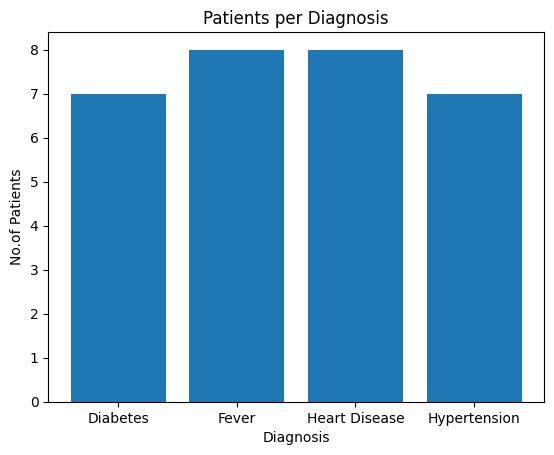

In [79]:
patients = df.groupby('diagnosis')['patient_id'].count()
plt.bar(patients.index,patients.values)
plt.xlabel("Diagnosis")
plt.ylabel("No.of Patients")
plt.title("Patients per Diagnosis")
plt.show()

In [77]:
patients

diagnosis
Diabetes         7
Fever            8
Heart Disease    8
Hypertension     7
Name: patient_id, dtype: int64

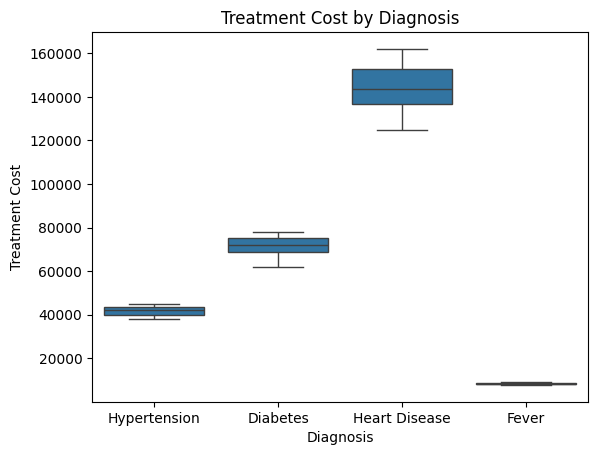

In [ ]:
sns.boxplot(data=df, x='diagnosis', y='treatment_cost')

# Add titles and labels for clarity
plt.title('Treatment Cost by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Treatment Cost')
plt.show()
